# Imports

In [1]:
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelBinarizer

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam

# Load dataset

In [2]:
(trainX, trainY), (testX, testY) = mnist.load_data()

# Normalizado a [0, 1]
trainX = trainX / 255.0
testX = testX / 255.0

train_labels = trainY
test_labels = testY

trainY = LabelBinarizer().fit_transform(trainY)
testY = LabelBinarizer().fit_transform(testY)

# Example of LabelBinarizer
# array([5, 0, 4, 1, 9], dtype=uint8)
# array([
#       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
#       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
#       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
#       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
# ])

display(train_labels[:5])
display(trainY[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


array([5, 0, 4, 1, 9], dtype=uint8)

array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

In [3]:
print("Train X dataset shape: ", np.shape(trainX))
print("Train y dataset shape: ", np.shape(trainY))
print("Test X dataset shape: ", np.shape(testX))
print("Test y dataset shape: ", np.shape(testY))

Train X dataset shape:  (60000, 28, 28)
Train y dataset shape:  (60000, 10)
Test X dataset shape:  (10000, 28, 28)
Test y dataset shape:  (10000, 10)


In [4]:
def show_examples(X, y_real, y_pred):
    fig, ax = plt.subplots(1, 5, figsize=[25, 5])

    for i, img in enumerate(X[:5]):
        ax[i].imshow(img, cmap='Greys')
        ax[i].set_title('y real: ' + str(y_real[i]) +
                        '\ny predicted: ' + str(y_pred[i]))
    plt.show()

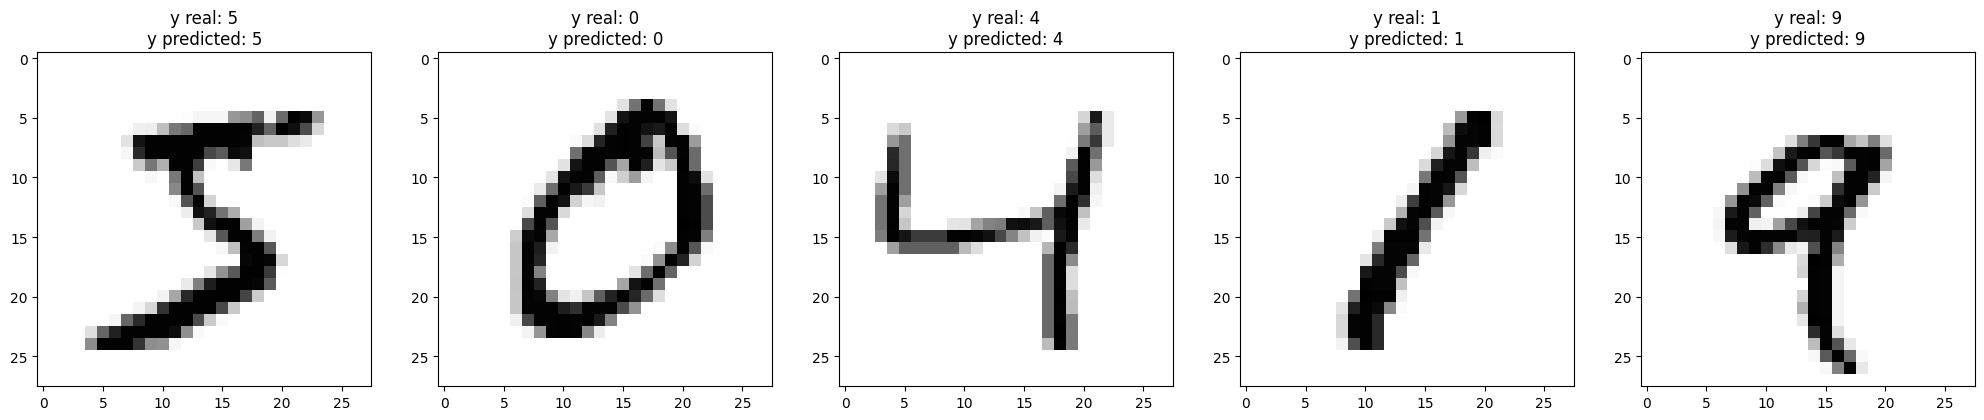

In [5]:
show_examples(trainX, train_labels, train_labels)

# Model definition

In [13]:
def create_classifier():
    # Este es un problema sencillo, no utilices muchos filtros.
    # Recuerda que MNIST son imágenes de 28x28 píxeles en escala de grises.
    # Por tanto, la entrada de la red tendrá forma (28, 28, 1)

    # Haz 2 Conv2d, luego redimensiona/aplana y haz una capa densa (o fc) para clasificar

    #Conv2D help: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D
    # Crea input y output

    # Entrada: imágenes 28x28 en escala de grises
    input_layer = Input(shape=(28, 28, 1)) # Primera convolución
    x = Conv2D( filters=16, kernel_size=(3, 3), activation='relu', padding='same')(input_layer)
    # Segunda convolución
    x = Conv2D( filters=32, kernel_size=(3, 3), activation='relu', padding='same')(x)
    # Aplanado
    x = Flatten()(x) # Capa densa final para 10 clases (0–9)
    output_layer = Dense(10, activation='softmax')(x)
    # Crear modelo
    model = Model(inputs=input_layer, outputs=output_layer)
    return model

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       250,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,690 (998.79 KB)

 Trainable params: 255,690 (998.79 KB)

 Non-trainable params: 0 (0.00 B)

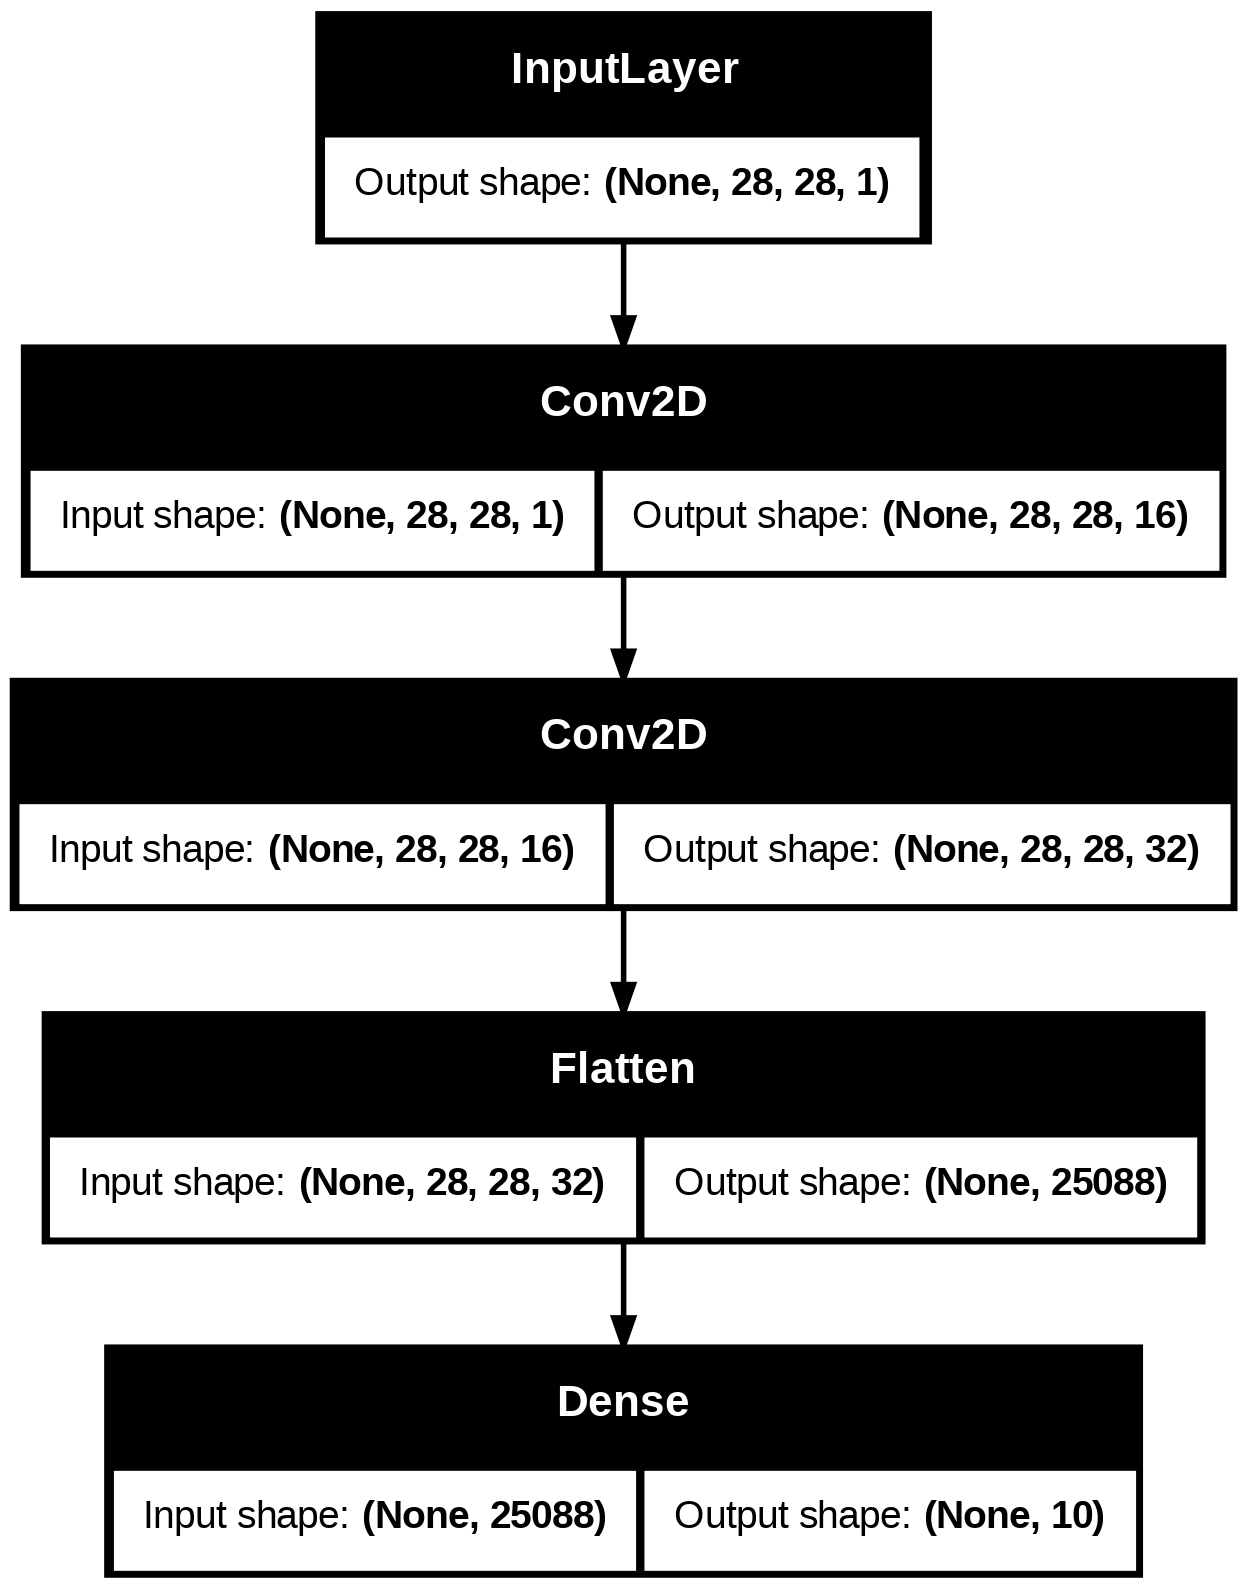

In [14]:
model = create_classifier()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False)

In [15]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

# Train model

In [16]:
history = model.fit(trainX, trainY, epochs=20, batch_size=128, validation_data=(testX, testY), verbose=1)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8722 - loss: 0.4082 - val_accuracy: 0.9786 - val_loss: 0.0691
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9805 - loss: 0.0660 - val_accuracy: 0.9821 - val_loss: 0.0561
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9856 - loss: 0.0467 - val_accuracy: 0.9878 - val_loss: 0.0411
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9893 - loss: 0.0366 - val_accuracy: 0.9872 - val_loss: 0.0407
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9919 - loss: 0.0276 - val_accuracy: 0.9873 - val_loss: 0.0396
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9931 - loss: 0.0218 - val_accuracy: 0.9855 - val_loss: 0.0493
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9953 - loss: 0.0164 - val_accuracy: 0.9848 - val_loss: 0.0552
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9961 - loss: 0.0138 - val_accuracy: 0.

# Evaluate the model

In [17]:
def plot_losses(history):
    plt.rcParams['figure.figsize'] = [20, 5]
    f, (ax1, ax2) = plt.subplots(1, 2, sharex=True)

    ax1.set_title('Losses')
    ax1.set_xlabel('epoch')
    ax1.legend(loc="upper right")
    ax1.grid()
    ax1.plot(history['loss'], label='Training loss')
    ax1.plot(history['val_loss'], label='Validation loss')
    ax1.legend()

    ax2.set_title('Accuracy')
    ax2.set_xlabel('epoch')
    ax2.legend(loc="upper right")
    ax2.grid()
    ax2.plot(history['accuracy'], label='Training accuracy')
    ax2.plot(history['val_accuracy'], label='Validation accuracy')
    ax2.legend()

    plt.show()

/tmp/ipython-input-217370305.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper right")
/tmp/ipython-input-217370305.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right")


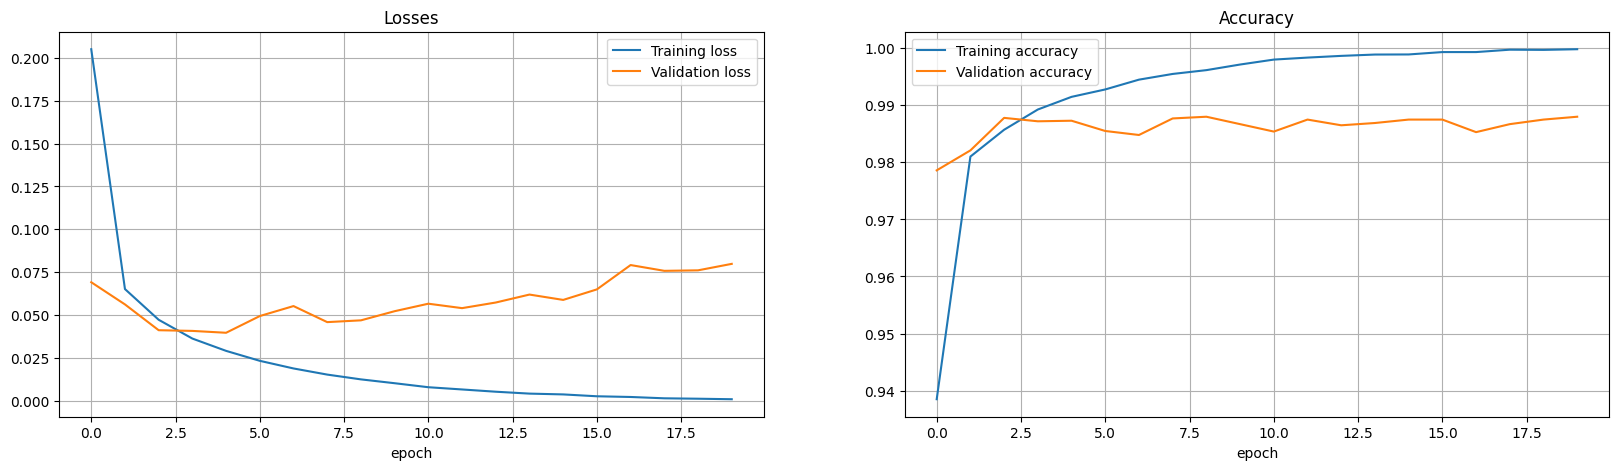

In [18]:
plot_losses(history.history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step


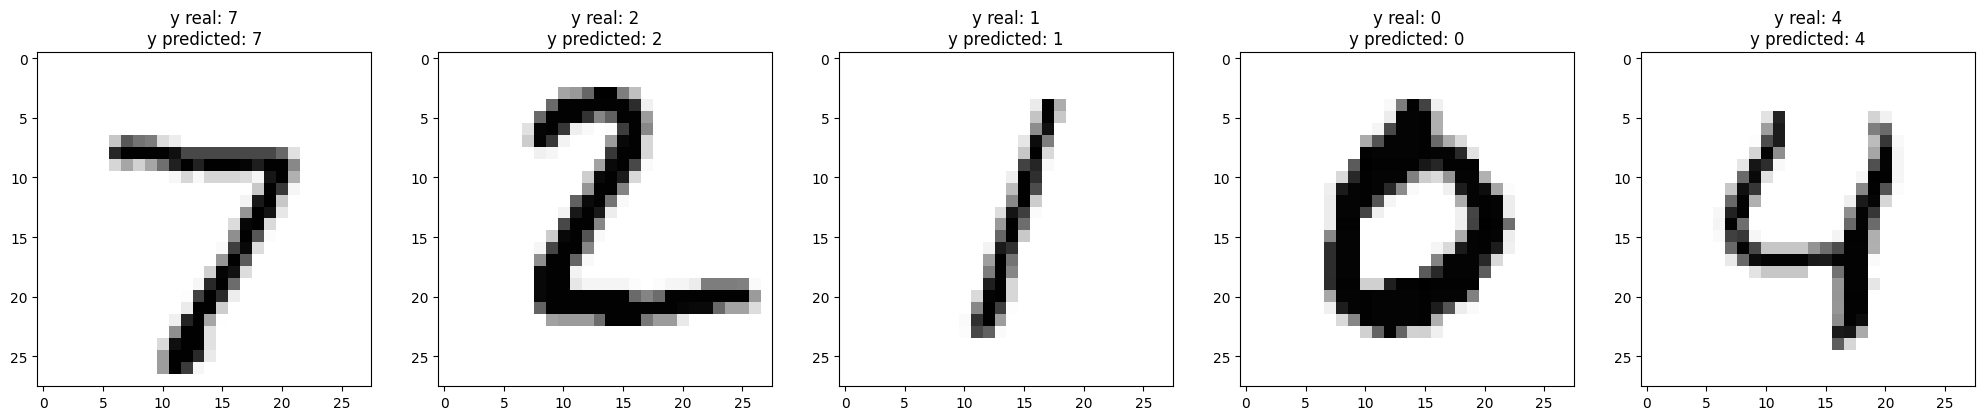

In [19]:
y_pred = model.predict(testX[:5]).argmax(axis=-1)

show_examples(testX[:5], test_labels[:5], y_pred)

---

Creado por **Guillermo Iglesias** (guillermo.iglesias@upm.es)

<img src="https://licensebuttons.net/l/by-nc-sa/3.0/88x31.png">